# import & 데이터 불러오기

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
# import koreanize_matplotlib
# import pingouin as pg
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib
import warnings
%matplotlib inline
 
warnings.filterwarnings(action='ignore')

pd.set_option("display.max_columns", 500)
pd.set_option('display.max_rows', 50)

# 폰트 파일 경로 (현재 디렉토리 기준)
font_path = './NanumGothic.ttf'

# 폰트 파일이 존재하는지 확인
if os.path.exists(font_path):
    # 폰트 등록
    nanum_font = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = nanum_font
    print(f"✅ 한글 폰트 적용 완료: {nanum_font}")
else:
    print("⚠️ NanumGothic.ttf 파일이 현재 경로에 없습니다. 한글 폰트가 깨질 수 있습니다.")

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# seaborn 스타일 및 폰트 적용
sns.set(
    font=plt.rcParams['font.family'],
    rc={"axes.unicode_minus": False, "figure.figsize": (20, 8)},
    style='darkgrid',
    font_scale=0.9
)

✅ 한글 폰트 적용 완료: NanumGothic


In [2]:
import pandas as pd
from functools import reduce
import os

DATA_PATH = "C:/Users/pjh98/Desktop/에듀테크 소프트랩 AI 해커톤/Data/"

# 병합할 파일 이름을 리스트로 정리합니다.
file_list = [
    "청년순이동률_시군구.csv",
    "1인당도시지역면적현황_시군구.csv",
    "GRDP_시군구.csv",
    "고령인구비율_시군구.csv",
    "교원_1인당_학생수_시도_시군구.csv",
    "유아_천명당_보육시설수_시도_시군구.csv",
    "인구_십만명당_문화기반시설수_시군구.csv",
    "인구_천명당_사업체수_시군구.csv",
    "인구_천명당_의료기관병상수_시군구.csv",
    "일반가구의_주택소유율_시군구.csv",
    "재정자립도_시군구.csv",
    "독거노인가구비율_시군구.csv"
]

# --- 2. 데이터 불러오기 ---
dataframes = {}
print("--- 데이터 파일 로드 시작 ---")
for file_name in file_list:
    file_path = os.path.join(DATA_PATH, file_name)
    if os.path.exists(file_path):
        try:
            # 대부분의 경우 cp949 인코딩으로 열립니다.
            dataframes[file_name] = pd.read_csv(file_path, encoding='cp949')
            print(f"✅ '{file_name}' 로드 성공.")
        except UnicodeDecodeError:
            # cp949로 실패 시 utf-8로 재시도합니다.
            dataframes[file_name] = pd.read_csv(file_path, encoding='utf-8')
            print(f"✅ '{file_name}' 로드 성공 (utf-8).")
        except Exception as e:
            print(f"❗️ '{file_name}' 로드 중 오류 발생: {e}")
    else:
        print(f"⚠️ '{file_name}' 파일이 경로에 없습니다. 병합에서 제외됩니다.")

# --- 3. 전처리 및 표준화 ---
print("\n--- 데이터 전처리 시작 ---")
processed_dfs = []
for name, df in dataframes.items():
    df_copy = df.copy()
    
    # '시점' 컬럼이 존재하면 '연도'로 변경
    if '시점' in df_copy.columns:
        df_copy.rename(columns={'시점': '연도'}, inplace=True)
    
    # 분석에 불필요한 '소계' 행 제거
    if '시군구' in df_copy.columns and '소계' in df_copy['시군구'].unique():
        df_copy = df_copy[df_copy['시군구'] != '소계']
        
    # 2018~2022년 데이터 필터링
    if '연도' in df_copy.columns:
        df_copy['연도'] = pd.to_numeric(df_copy['연도'])
        df_copy = df_copy[(df_copy['연도'] >= 2018) & (df_copy['연도'] <= 2022)]
    
    processed_dfs.append(df_copy)

print("✅ '소계' 행 제거 및 2018-2022년 필터링 완료.")

# --- 4. 병합 전 '시군구' 명칭 일관성 확인 ---
print("\n--- '시군구' 명칭 일관성 확인 시작 ---")
if processed_dfs:
    # 첫 번째 데이터프레임을 기준으로 시군구 목록 생성
    reference_sigungu = set(processed_dfs[0]['시군구'].unique())
    print(f"기준 시군구 목록 (총 {len(reference_sigungu)}개)")

    all_match = True
    # 두 번째 데이터프레임부터 순차적으로 비교
    for i, df in enumerate(processed_dfs[1:]):
        current_sigungu = set(df['시군구'].unique())
        if reference_sigungu != current_sigungu:
            all_match = False
            print(f"\n❗️ '{list(dataframes.keys())[i+1]}' 파일의 '시군구' 목록이 기준과 다릅니다.")
            if len(reference_sigungu - current_sigungu) > 0:
                print(f"  - 기준에만 있는 시군구: {sorted(list(reference_sigungu - current_sigungu))}")
            if len(current_sigungu - reference_sigungu) > 0:
                print(f"  - 현재 파일에만 있는 시군구: {sorted(list(current_sigungu - reference_sigungu))}")

    if all_match:
        print("✅ 모든 데이터의 '시군구' 목록이 완벽하게 일치합니다.")
else:
    print("❗️ 처리할 데이터프레임이 없어 확인을 건너뜁니다.")


# --- 5. 데이터 병합 ---
print("\n--- 데이터 병합 시작 ---")
if len(processed_dfs) > 1:
    # 병합의 기준이 될 키 컬럼들
    merge_keys = ['시도', '시군구', '연도']
    
    # functools.reduce를 사용하여 모든 데이터프레임을 순차적으로 병합
    # how='outer'로 설정하여 데이터 손실을 방지합니다.
    df_merged = reduce(lambda left, right: pd.merge(left, right, on=merge_keys, how='outer'), processed_dfs)
    print("✅ 데이터 병합 완료.")

    # --- 6. 병합 후 최종 확인 ---
    print("\n--- 최종 병합 결과 확인 ---")
    print(f"최종 데이터 형태 (행, 열): {df_merged.shape}")
    print(f"'시군구' 고유값 개수: {df_merged['시군구'].nunique()}")
    print(f"'연도' 고유값 개수: {df_merged['연도'].nunique()}")
    print(f"'연도' 목록: {sorted(df_merged['연도'].unique())}")

    # 결측치 확인 (outer join으로 인해 발생 가능)
    missing_values = df_merged.isnull().sum()
    print("\n[결측치 확인]")
    print(missing_values[missing_values > 0])
    
    # --- 7. 최종 파일 저장 ---
    output_filename = "강원도_시군구_통합_데이터.csv"
    output_path = os.path.join(DATA_PATH, output_filename)
    df_merged.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n🎉 최종 병합 파일이 '{output_path}' 경로에 저장되었습니다.")
    
elif len(processed_dfs) == 1:
    print("⚠️ 데이터 파일이 하나만 있어 병합을 진행하지 않습니다.")
else:
    print("❗️ 병합할 데이터 파일이 없습니다. 파일 경로와 목록을 다시 확인해주세요.")

--- 데이터 파일 로드 시작 ---
✅ '청년순이동률_시군구.csv' 로드 성공.
✅ '1인당도시지역면적현황_시군구.csv' 로드 성공.
✅ 'GRDP_시군구.csv' 로드 성공.
✅ '고령인구비율_시군구.csv' 로드 성공.
✅ '교원_1인당_학생수_시도_시군구.csv' 로드 성공.
✅ '유아_천명당_보육시설수_시도_시군구.csv' 로드 성공.
✅ '인구_십만명당_문화기반시설수_시군구.csv' 로드 성공.
✅ '인구_천명당_사업체수_시군구.csv' 로드 성공.
✅ '인구_천명당_의료기관병상수_시군구.csv' 로드 성공.
✅ '일반가구의_주택소유율_시군구.csv' 로드 성공.
✅ '재정자립도_시군구.csv' 로드 성공.
✅ '독거노인가구비율_시군구.csv' 로드 성공.

--- 데이터 전처리 시작 ---
✅ '소계' 행 제거 및 2018-2022년 필터링 완료.

--- '시군구' 명칭 일관성 확인 시작 ---
기준 시군구 목록 (총 18개)
✅ 모든 데이터의 '시군구' 목록이 완벽하게 일치합니다.

--- 데이터 병합 시작 ---
✅ 데이터 병합 완료.

--- 최종 병합 결과 확인 ---
최종 데이터 형태 (행, 열): (90, 46)
'시군구' 고유값 개수: 18
'연도' 고유값 개수: 5
'연도' 목록: [2018, 2019, 2020, 2021, 2022]

[결측치 확인]
당해년가격(단위: 백만원)          18
2015년 기준년가격(단위: 백만원)    18
dtype: int64

🎉 최종 병합 파일이 'C:/Users/pjh98/Desktop/에듀테크 소프트랩 AI 해커톤/Data/강원도_시군구_통합_데이터.csv' 경로에 저장되었습니다.


# 데이터 전처리

In [3]:
import pandas as pd
from functools import reduce
import os
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

# --- 0. 기본 경로 설정 ---
# !!! 중요 !!!
# 사용자의 데이터 파일이 저장된 폴더 경로를 정확하게 입력해주세요.
DATA_PATH = "C:/Users/pjh98/Desktop/에듀테크 소프트랩 AI 해커톤/Data/"

# --- 1. 교통 접근성 데이터 3종 불러오기 ---
print("--- 1. 교통 접근성 데이터 로드 시작 ---")
try:
    tr_1 = pd.read_csv(f"{DATA_PATH}강원도_시군구_행정구역,시설,시간대,교통수단별_접근가능시설수.csv", encoding="cp949")
    tr_2 = pd.read_csv(f"{DATA_PATH}강원도_시군구_행정구역,시설,시간대,교통수단별_접근가능인구비율.csv", encoding="cp949")
    tr_3 = pd.read_csv(f"{DATA_PATH}강원도_시군구_행정구역,시설,시간대,교통수단별_평균접근시간.csv", encoding="cp949")
    
    print("✅ 교통 접근성 데이터 3종 로드 성공.")
    
    transport_dfs = [tr_1, tr_2, tr_3]
    
    # --- 2. 교통 데이터 전처리 (소계 제거 및 컬럼 정리) ---
    print("\n--- 2. 교통 데이터 전처리 시작 ---")
    processed_tr_dfs = []
    
    for df in transport_dfs:
        df_copy = df.copy()
        
        # '소계' 행 제거
        if '시군구' in df_copy.columns and '소계' in df_copy['시군구'].unique():
            df_copy = df_copy[df_copy['시군구'] != '소계']
            
        # 병합에 불필요한 '행정구역코드' 컬럼 제거
        if '행정구역코드' in df_copy.columns:
            df_copy = df_copy.drop(columns=['행정구역코드'])
            
        # 연도 타입 통일
        if '연도' in df_copy.columns:
            df_copy['연도'] = df_copy['연도'].astype(int)
            
        processed_tr_dfs.append(df_copy)
    
    print("✅ '소계' 행 제거 및 '행정구역코드' 컬럼 제거 완료.")

    # --- 3. 교통 데이터 3종 병합 ---
    print("\n--- 3. 교통 데이터 3종 병합 시작 ---")
    merge_keys = ['시도', '시군구', '연도']
    
    # reduce를 사용하여 3개의 데이터프레임을 순차적으로 병합
    df_transport_merged = reduce(lambda left, right: pd.merge(left, right, on=merge_keys, how='outer'), 
                                 processed_tr_dfs)
    
    print(f"✅ 교통 데이터 병합 완료. 형태: {df_transport_merged.shape}")
    
    # 병합 결과 확인
    print("\n[교통 데이터 병합 후 정보]")
    df_transport_merged.info()

except FileNotFoundError as e:
    print(f"❗️ [오류] 파일을 찾을 수 없습니다: {e}")
    print("❗️ DATA_PATH 변수의 경로가 올바른지 다시 확인해주세요.")
except UnicodeDecodeError as e:
    print(f"❗️ [오류] 인코딩 문제가 발생했습니다: {e}")
    print("❗️ tr_3 파일의 인코딩을 'cp949', 'utf-8', 'cp437' 등으로 변경하며 시도해보세요.")
except Exception as e:
    print(f"❗️ [알 수 없는 오류] {e}")

--- 1. 교통 접근성 데이터 로드 시작 ---
✅ 교통 접근성 데이터 3종 로드 성공.

--- 2. 교통 데이터 전처리 시작 ---
✅ '소계' 행 제거 및 '행정구역코드' 컬럼 제거 완료.

--- 3. 교통 데이터 3종 병합 시작 ---
✅ 교통 데이터 병합 완료. 형태: (90, 75)

[교통 데이터 병합 후 정보]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 75 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   연도                                 90 non-null     int32  
 1   시도                                 90 non-null     object 
 2   시군구                                90 non-null     object 
 3   광역교통시설_대중교통/도보_15분 이내_접근가능시설수(개)   90 non-null     float64
 4   광역교통시설_대중교통/도보_30분 이내_접근가능시설수(개)   90 non-null     float64
 5   광역교통시설_대중교통/도보_45분 이내_접근가능시설수(개)   90 non-null     float64
 6   광역교통시설_대중교통/도보_60분 이내_접근가능시설수(개)   90 non-null     float64
 7   광역교통시설_승용차_15분 이내_접근가능시설수(개)       90 non-null     float64
 8   광역교통시설_승용차_30분 이내_접근가능시설수(개)       90 non-null     float64
 9   광역교

## 데이터 결측치 처리

In [4]:
# --- 5. GRDP 결측치 처리 (Forward Fill) ---
print("\n--- 5. GRDP 결측치 처리 시작 ---")
grdp_cols = ['당해년가격(단위: 백만원)', '2015년 기준년가격(단위: 백만원)']

# 결측치가 있는 컬럼이 df_merged에 있는지 확인
if all(col in df_merged.columns for col in grdp_cols):
    print(f"처리 전 결측치 수:\n{df_merged[grdp_cols].isnull().sum()}")
    
    # 1. 시군구별, 연도별로 정렬 (ffill을 위해 필수)
    df_merged_sorted = df_merged.sort_values(by=['시군구', '연도'])
    
    # 2. 시군구별로 그룹화하여 ffill(forward fill) 적용
    # 2021년 값으로 2022년 NaN을 채웁니다.
    df_merged_imputed = df_merged_sorted.copy()
    df_merged_imputed[grdp_cols] = df_merged_imputed.groupby('시군구')[grdp_cols].ffill()
    
    # (안전장치) 혹시 2018년 값이 비어있을 경우 bfill(backward fill)로 채움
    df_merged_imputed[grdp_cols] = df_merged_imputed.groupby('시군구')[grdp_cols].bfill()

    print("\n처리 후 결측치 수:")
    print(df_merged_imputed[grdp_cols].isnull().sum())
    print("✅ GRDP 결측치 처리 완료.")
else:
    print("❗️ GRDP 컬럼이 원본 데이터에 없습니다. 결측치 처리를 건너뜁니다.")
    df_merged_imputed = df_merged.copy()


--- 5. GRDP 결측치 처리 시작 ---
처리 전 결측치 수:
당해년가격(단위: 백만원)          18
2015년 기준년가격(단위: 백만원)    18
dtype: int64

처리 후 결측치 수:
당해년가격(단위: 백만원)          0
2015년 기준년가격(단위: 백만원)    0
dtype: int64
✅ GRDP 결측치 처리 완료.


In [5]:
# --- 6. 최종 병합 전 '시군구' 명칭 일관성 확인 ---
print("\n--- 6. 최종 병합 전 '시군구' 명칭 일관성 확인 ---")

# df_merged_imputed와 df_transport_merged가 모두 정의되었는지 확인
if 'df_merged_imputed' in locals() and 'df_transport_merged' in locals():
    
    sigungu_social = set(df_merged_imputed['시군구'].unique())
    sigungu_transport = set(df_transport_merged['시군구'].unique())

    if sigungu_social == sigungu_transport:
        print(f"✅ '시군구' 명칭 일치 (총 {len(sigungu_social)}개). 병합을 진행합니다.")
        
        # --- 7. 최종 데이터 병합 ---
        print("\n--- 7. 최종 데이터 병합 ---")
        df_final = pd.merge(df_merged_imputed, df_transport_merged, on=['시도', '시군구', '연도'], how='inner')
        
        print(f"✅ 최종 병합 완료. 최종 데이터 형태: {df_final.shape}")
        
    else:
        print("❗️ [오류] '시군구' 명칭 불일치!")
        if len(sigungu_social - sigungu_transport) > 0:
            print(f"  - 사회통계 데이터에만 있음: {sigungu_social - sigungu_transport}")
        if len(sigungu_transport - sigungu_social) > 0:
            print(f"  - 교통 데이터에만 있음: {sigungu_transport - sigungu_social}")

else:
    print("❗️ [오류] 이전 단계에서 데이터가 제대로 로드/처리되지 않았습니다. 병합을 중단합니다.")


--- 6. 최종 병합 전 '시군구' 명칭 일관성 확인 ---
✅ '시군구' 명칭 일치 (총 18개). 병합을 진행합니다.

--- 7. 최종 데이터 병합 ---
✅ 최종 병합 완료. 최종 데이터 형태: (90, 118)


In [6]:
# --- 8. 최종 데이터셋 간단 EDA 및 저장 ---
print("\n--- 8. 최종 데이터셋 EDA 및 저장 ---")

if 'df_final' in locals():
    # 1. 최종 결측치 확인
    print("\n[최종 결측치 확인]")
    final_na = df_final.isnull().sum().sum()
    if final_na > 0:
        print(f"❗️ 최종 데이터에 {final_na}개의 결측치가 남아있습니다. 확인이 필요합니다.")
        print(df_final.isnull().sum()[df_final.isnull().sum() > 0])
    else:
        print("✅ 최종 데이터에 결측치가 없습니다.")

    # 2. 데이터 타입 확인
    print("\n[데이터 타입 확인 (일부)]")
    print(df_final.info())

    # 3. 기본 통계량 확인 (수치형 데이터)
    print("\n[기본 통계량 요약 (T)]")
    # .T (Transpose)를 하여 가로로 길게 보는 것이 편리합니다.
    pd.set_option('display.max_rows', None) # 모든 행을 다 보도록 설정
    pd.set_option('display.max_columns', None) # 모든 열을 다 보도록 설정
    print(df_final.describe().T)
    pd.reset_option('display.max_rows') # 설정 리셋
    pd.reset_option('display.max_columns') # 설정 리셋

    # 4. 최종 파일 저장
    final_output_path = os.path.join(DATA_PATH, "강원도_시군구_최종데이터.csv")
    df_final.to_csv(final_output_path, index=False, encoding='utf-8')
    print(f"\n🎉 최종 통합 파일이 '{final_output_path}' 경로에 저장되었습니다.")

else:
    print("❗️ [오류] 'df_final'이 생성되지 않아 EDA를 스킵합니다.")


--- 8. 최종 데이터셋 EDA 및 저장 ---

[최종 결측치 확인]
✅ 최종 데이터에 결측치가 없습니다.

[데이터 타입 확인 (일부)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Columns: 118 entries, 시도 to 판매시설_승용차_평균접근시간(분)
dtypes: float64(90), int64(23), object(5)
memory usage: 83.1+ KB
None

[기본 통계량 요약 (T)]
                                   count          mean           std  \
연도                                  90.0  2.020000e+03  1.422136e+00   
청년순이동률(19~39세) (%)                  90.0 -3.296667e+00  3.314573e+00   
청년순이동(19~39세) (명)                   90.0 -2.316444e+02  5.208018e+02   
청년연앙인구(19~39세) (명)                  90.0  2.021950e+04  2.511828e+04   
청년순이동률(19~34세) (%)                  90.0 -4.242222e+00  3.777193e+00   
청년순이동(19~34세) (명)                   90.0 -2.737222e+02  4.072012e+02   
청년연앙인구(19~34세) (명)                  90.0  1.511351e+04  1.864589e+04   
도시지역 인구                             90.0  7.046504e+04  8.888915e+04   
도시지역 면적(단위: ㎡)                      90.0  5.718890e+07  7.560401e+0

# 데이터 스케일링

In [26]:
import pandas as pd
import numpy as np

# --- 1. 데이터 로드 및 타입 강제 변환 ---
print("--- 1. 데이터 로드 및 오류 자동 수정 ---")
try:
    df_final = pd.read_csv(f"{DATA_PATH}강원도_시군구_최종데이터.csv", encoding='utf-8')
    print(f"✅ 원본 데이터 로드 성공. 형태: {df_final.shape}")

    # 식별자 컬럼('시도', '시군구')을 제외한 모든 컬럼을 숫자형으로 변환 시도
    # pd.to_numeric의 errors='coerce' 옵션은 숫자로 바꿀 수 없는 값을 강제로 NaN(결측치)으로 만듭니다.
    cols_to_convert = df_final.columns.drop(['시도', '시군구'])
    df_final[cols_to_convert] = df_final[cols_to_convert].apply(pd.to_numeric, errors='coerce')

    print("\n✅ 모든 컬럼에 대해 숫자형 변환 시도 완료.")
    print("   - 숫자로 변환할 수 없는 값(예: '-')은 결측치(NaN)로 자동 처리되었습니다.")

    # 변환 후 결측치가 얼마나 생겼는지 확인
    print("\n[새롭게 생성된 결측치 현황]")
    na_report = df_final.isnull().sum()
    print(na_report[na_report > 0])

except FileNotFoundError:
    print("❗️ [오류] '강원도_시군구_최종데이터.csv' 파일을 찾을 수 없습니다.")
except Exception as e:
    print(f"❗️ [알 수 없는 오류] {e}")

--- 1. 데이터 로드 및 오류 자동 수정 ---
✅ 원본 데이터 로드 성공. 형태: (90, 118)

✅ 모든 컬럼에 대해 숫자형 변환 시도 완료.
   - 숫자로 변환할 수 없는 값(예: '-')은 결측치(NaN)로 자동 처리되었습니다.

[새롭게 생성된 결측치 현황]
공업지역(단위: ㎡)                      1
인구 천명당 의료기관병상수(A÷B×1000) (개)    10
총병상수(A) (개)                     10
dtype: int64


In [27]:
df_final.head(1)

,시도,시군구,연도,청년순이동률(19~39세) (%),청년순이동(19~39세) (명),청년연앙인구(19~39세) (명),청년순이동률(19~34세) (%),청년순이동(19~34세) (명),청년연앙인구(19~34세) (명),도시지역 인구,...,판매시설_승용차_45분 이내_접근가능인구비율(%),판매시설_승용차_60분 이내_접근가능인구비율(%),광역교통시설_대중교통/도보_평균접근시간(분),광역교통시설_승용차_평균접근시간(분),교육시설_대중교통/도보_평균접근시간(분),교육시설_승용차_평균접근시간(분),의료시설_대중교통/도보_평균접근시간(분),의료시설_승용차_평균접근시간(분),판매시설_대중교통/도보_평균접근시간(분),판매시설_승용차_평균접근시간(분)
0,강원특별자치도,강릉시,2018,-1.9,-986,51052,-2.8,-1063,37607,185570,...,98.72,99.63,65.83,27.97,20.67,6.47,27.84,8.7,35.76,13.0


In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

# 분석에 사용할 수치형 컬럼만 선택
# '시도', '시군구', '연도'는 식별자이므로 제외
identifier_cols = ['시도', '시군구', '연도']
numeric_cols = df_final.select_dtypes(include=np.number).columns.tolist()

# 연도는 수치형이지만 특성 분석에서는 제외
if '연도' in numeric_cols:
    numeric_cols.remove('연도')

print(f"✅ 식별자 컬럼 수: {len(identifier_cols)}")
print(f"✅ 분석 대상 수치형 컬럼 수: {len(numeric_cols)}")


✅ 식별자 컬럼 수: 3
✅ 분석 대상 수치형 컬럼 수: 115


- 선형보간

In [29]:
# --- 2. (수정) 3단계 결측치 처리 ---
print("\n--- 2. 3단계 결측치 처리 시작 ---")

# 1. 연도 순으로 데이터 정렬
df_final_sorted = df_final.sort_values(by=['시군구', '연도']).reset_index(drop=True)

# 2. 시군구별로 그룹화하여 3단계 결측치 처리 적용
# 먼저 interpolate로 중간값을 채우고, ffill로 뒷부분을, bfill로 앞부분을 채웁니다.
imputed_data = df_final_sorted.groupby('시군구').transform(
    lambda x: x.interpolate().ffill().bfill()
)

# 식별자 컬럼은 원본 값으로 다시 복원
imputed_data[['시도', '시군구', '연도']] = df_final_sorted[['시도', '시군구', '연도']]

# (안전장치) 만약 특정 시군구의 컬럼 전체가 비어있을 경우, 0으로 채웁니다.
df_final_imputed = imputed_data.fillna(0)


# 3. 보간 후 결측치 최종 확인
remaining_na = df_final_imputed.isnull().sum().sum()
if remaining_na == 0:
    print(f"✅ 모든 결측치 처리 완료. 남은 결측치: {remaining_na}개")
else:
    print(f"❗️ 처리 후에도 {remaining_na}개의 결측치가 남아있습니다.")


--- 2. 3단계 결측치 처리 시작 ---
✅ 모든 결측치 처리 완료. 남은 결측치: 0개


# 파생변수 생성 및 차원축소

In [30]:
# # --- 2. 특성 공학 (Feature Engineering) ---
# print("\n--- 2. 특성 공학 (평균 및 변화 추세 추출) ---")

# # 시군구 목록
# sigungu_list = df_final['시군구'].unique()

# # 1. 5년 평균 특성 계산
# # 각 시군구별로 모든 수치형 컬럼의 5년 평균을 계산
# df_mean_features = df_final.groupby('시군구')[numeric_cols].mean()
# print(f"✅ 5년 평균 특성 데이터 생성 완료. 형태: {df_mean_features.shape}")


# # 2. 변화 추세 특성 계산 (핵심 변수 대상)
# # 추세를 분석할 주요 변수 선택
# trend_cols = [
#     '청년순이동률(19~39세) (%)',
#     '고령인구비율(A÷B×100) (%)',
#     '당해년가격(단위: 백만원)', # GRDP
#     '재정자립도(세입과목개편후)',
#     '인구 천명당 의료기관병상수(A÷B×1000) (개)',
#     '의료시설_대중교통/도보_평균접근시간(분)'
# ]

# # 결과를 저장할 데이터프레임 초기화
# df_trend_features = pd.DataFrame(index=sigungu_list)

# # 각 시군구 및 주요 변수에 대해 선형 회귀를 적용하여 기울기(추세) 계산
# for col in trend_cols:
#     slopes = []
#     for sigungu in sigungu_list:
#         subset = df_final[df_final['시군구'] == sigungu]
        
#         # X는 연도, y는 해당 변수의 값
#         X = subset[['연도']].values
#         y = subset[col].values
        
#         # 선형 회귀 모델 학습
#         model = LinearRegression()
#         model.fit(X, y)
        
#         # 계산된 기울기(연간 변화량)를 리스트에 추가
#         slopes.append(model.coef_[0])
        
#     # 데이터프레임에 새로운 '변수명_추세' 컬럼으로 추가
#     df_trend_features[f'{col}_추세'] = slopes

# print(f"✅ 변화 추세 특성 데이터 생성 완료. 형태: {df_trend_features.shape}")


# # 3. 평균 특성과 변화 추세 특성 결합
# df_engineered = pd.concat([df_mean_features, df_trend_features], axis=1)
# print(f"✅ 최종 특성 데이터 결합 완료. 형태: {df_engineered.shape}")
# print("\n[생성된 특성 데이터 샘플 (상위 5개)]")
# print(df_engineered.head())


--- 3. 특성 공학 진행 ---
✅ 특성 공학 완료. 최종 특성 데이터 형태: (18, 121)

--- 4. 데이터 스케일링 및 PCA ---
✅ 스케일링 및 PCA 적용 완료.


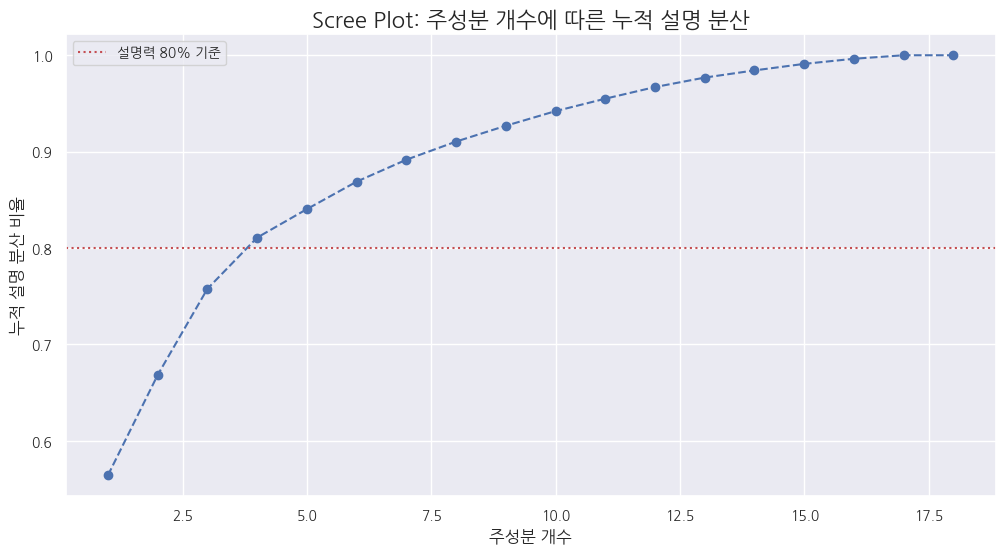

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# --- 3. 특성 공학 (평균 및 변화 추세 추출) ---
print("\n--- 3. 특성 공학 진행 ---")

# 분석에 사용할 수치형 컬럼 목록 생성 (식별자 제외)
numeric_cols = df_final_imputed.select_dtypes(include=np.number).columns.drop('연도').tolist()
sigungu_list = df_final_imputed['시군구'].unique()

# 1. 5년 평균 특성 계산
df_mean_features = df_final_imputed.groupby('시군구')[numeric_cols].mean()

# 2. 변화 추세 특성 계산
trend_cols = [
    '청년순이동률(19~39세) (%)', '고령인구비율(A÷B×100) (%)', '당해년가격(단위: 백만원)',
    '재정자립도(세입과목개편후)', '인구 천명당 의료기관병상수(A÷B×1000) (개)',
    '의료시설_대중교통/도보_평균접근시간(분)'
]
df_trend_features = pd.DataFrame(index=sigungu_list)

for col in trend_cols:
    slopes = []
    for sigungu in sigungu_list:
        subset = df_final_imputed[df_final_imputed['시군구'] == sigungu]
        X = subset[['연도']].values
        y = subset[col].values
        model = LinearRegression()
        model.fit(X, y)
        slopes.append(model.coef_[0])
    df_trend_features[f'{col}_추세'] = slopes

# 3. 평균 특성과 변화 추세 특성 결합
df_engineered = pd.concat([df_mean_features, df_trend_features], axis=1)
print("✅ 특성 공학 완료. 최종 특성 데이터 형태:", df_engineered.shape)


# --- 4. 데이터 스케일링 및 PCA ---
print("\n--- 4. 데이터 스케일링 및 PCA ---")

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_engineered)
pca = PCA()
principal_components = pca.fit_transform(scaled_features)
print("✅ 스케일링 및 PCA 적용 완료.")

# Scree Plot 시각화
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Scree Plot: 주성분 개수에 따른 누적 설명 분산', fontsize=16)
plt.xlabel('주성분 개수', fontsize=12)
plt.ylabel('누적 설명 분산 비율', fontsize=12)
plt.grid(True)
plt.axhline(y=0.8, color='r', linestyle=':', label='설명력 80% 기준')
plt.legend()
plt.show()


--- 4. 최적 주성분 개수 시각화 및 최종 데이터 생성 ---


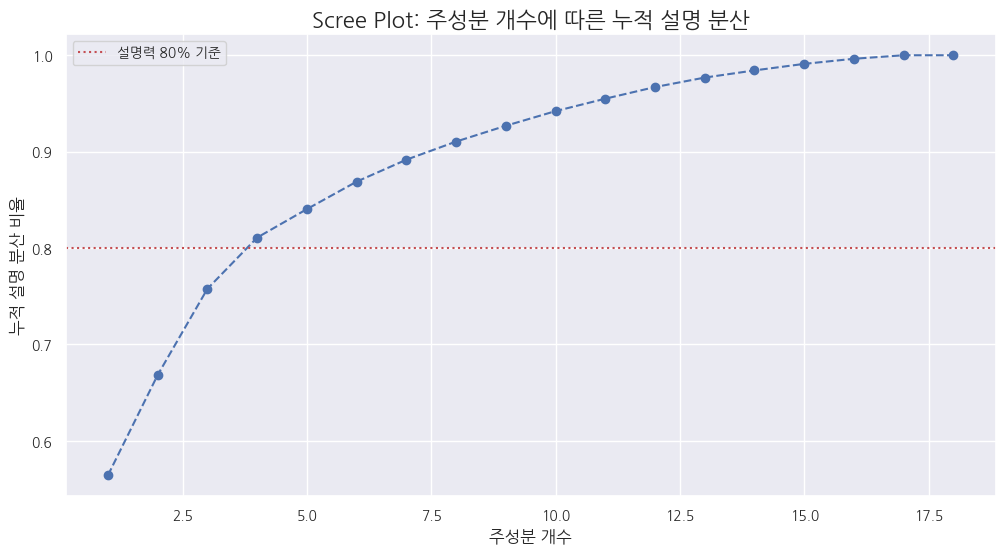

📈 스크리 플롯을 통해 주성분 개수를 결정하세요 (그래프의 '팔꿈치' 부분 또는 80% 기준선).

최종 주성분 개수를 5개로 결정하여 데이터를 생성합니다.

✅ 최종 PCA 변환 데이터 생성 완료. 형태: (18, 5)

[최종 PCA 데이터 (상위 5개)]
          PC1       PC2       PC3       PC4       PC5
강릉시  8.971157 -2.749184  1.225026  0.921273  1.175081
고성군 -5.152936  0.976268  0.376277  2.362846  4.485158
동해시  9.031397  6.428817 -0.332479  0.771179 -1.157377
삼척시  1.064848  2.621785  2.012496  0.944214  0.512260
속초시  7.378160  4.978464 -4.001976  4.987516  0.329069


In [32]:
# --- 4. 최적 주성분 개수 시각화 및 최종 데이터 생성 ---
print("\n--- 4. 최적 주성분 개수 시각화 및 최종 데이터 생성 ---")

# 1. 스크리 플롯 (Scree Plot) 시각화
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Scree Plot: 주성분 개수에 따른 누적 설명 분산', fontsize=16)
plt.xlabel('주성분 개수', fontsize=12)
plt.ylabel('누적 설명 분산 비율', fontsize=12)
plt.grid(True)
# 80% 기준선 추가
plt.axhline(y=0.8, color='r', linestyle=':', label='설명력 80% 기준')
plt.legend()
plt.show()

print("📈 스크리 플롯을 통해 주성분 개수를 결정하세요 (그래프의 '팔꿈치' 부분 또는 80% 기준선).")


# 2. 최종 PCA 데이터프레임 생성
# 위 그래프를 보고 최적의 주성분 개수(n)를 결정합니다.
# 예시: 5개로 결정
n_components_final = 5 
print(f"\n최종 주성분 개수를 {n_components_final}개로 결정하여 데이터를 생성합니다.")

# 최종 주성분 데이터프레임 생성
pc_columns = [f'PC{i+1}' for i in range(n_components_final)]
df_pca_final = pd.DataFrame(data=principal_components[:, :n_components_final], 
                            columns=pc_columns, 
                            index=sigungu_list)

print(f"\n✅ 최종 PCA 변환 데이터 생성 완료. 형태: {df_pca_final.shape}")
print("\n[최종 PCA 데이터 (상위 5개)]")
print(df_pca_final.head())

# 군집분석

--- 1. 최적의 K를 찾기 위한 지표 계산 시작 ---
  - K=2, Inertia: 823.16, Silhouette Score: 0.4719
  - K=3, Inertia: 567.95, Silhouette Score: 0.3739
  - K=4, Inertia: 400.58, Silhouette Score: 0.3189
  - K=5, Inertia: 343.70, Silhouette Score: 0.2716
  - K=6, Inertia: 291.64, Silhouette Score: 0.2429
  - K=7, Inertia: 246.11, Silhouette Score: 0.2449
  - K=8, Inertia: 161.43, Silhouette Score: 0.2739
  - K=9, Inertia: 142.28, Silhouette Score: 0.2321
  - K=10, Inertia: 121.81, Silhouette Score: 0.2076
✅ 지표 계산 완료.

--- 2. 결과 시각화 ---


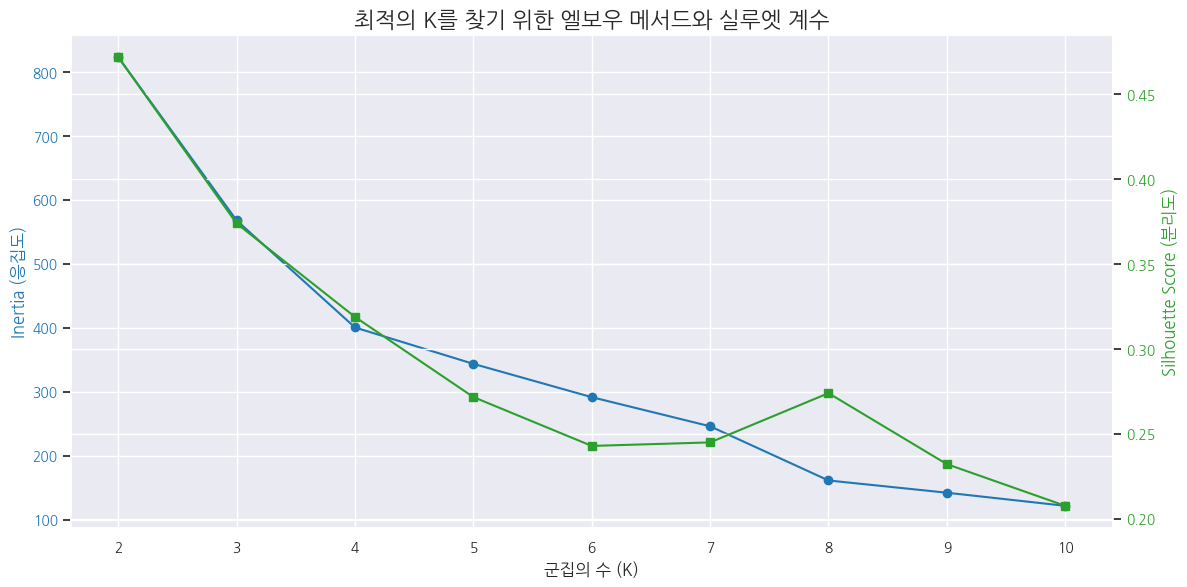


📈 위 그래프를 통해 최적의 K를 판단합니다.
   - (파란색) 엘보우 메서드: 그래프가 팔꿈치처럼 급격히 꺾이는 지점 (예: K=3 또는 4)
   - (초록색) 실루엣 계수: 가장 높은 값을 가지는 지점


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 최적의 K를 찾기 위한 지표 계산 ---
print("--- 1. 최적의 K를 찾기 위한 지표 계산 시작 ---")
k_range = range(2, 11) # K를 2부터 10까지 테스트
inertia_values = []
silhouette_scores = []

for k in k_range:
    # K-Means 모델 생성 및 학습
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_pca_final)
    
    # Inertia 값 저장 (군집 내 데이터들이 얼마나 뭉쳐있는지)
    inertia_values.append(kmeans.inertia_)
    
    # 실루엣 점수 계산 및 저장 (군집들이 얼마나 잘 분리되었는지)
    score = silhouette_score(df_pca_final, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"  - K={k}, Inertia: {kmeans.inertia_:.2f}, Silhouette Score: {score:.4f}")

print("✅ 지표 계산 완료.")


# --- 2. 엘보우 메서드 및 실루엣 계수 시각화 ---
print("\n--- 2. 결과 시각화 ---")
fig, ax1 = plt.subplots(figsize=(12, 6))

# 첫 번째 Y축 (Inertia - 엘보우)
color_1 = 'tab:blue'
ax1.set_title('최적의 K를 찾기 위한 엘보우 메서드와 실루엣 계수', fontsize=16)
ax1.set_xlabel('군집의 수 (K)', fontsize=12)
ax1.set_ylabel('Inertia (응집도)', fontsize=12, color=color_1)
ax1.plot(k_range, inertia_values, 'o-', color=color_1, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color_1)

# 두 번째 Y축 (Silhouette Score)
ax2 = ax1.twinx()
color_2 = 'tab:green'
ax2.set_ylabel('Silhouette Score (분리도)', fontsize=12, color=color_2)
ax2.plot(k_range, silhouette_scores, 's-', color=color_2, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color_2)

fig.tight_layout()
plt.grid(True, axis='x')
plt.show()

print("\n📈 위 그래프를 통해 최적의 K를 판단합니다.")
print("   - (파란색) 엘보우 메서드: 그래프가 팔꿈치처럼 급격히 꺾이는 지점 (예: K=3 또는 4)")
print("   - (초록색) 실루엣 계수: 가장 높은 값을 가지는 지점")

- K-means

In [34]:
# --- 3. K-Means 군집분석 실행 ---
print("\n--- 3. K-Means 군집분석 실행 ---")

# 위 그래프를 보고 최적의 K 결정 (엘보우와 실루엣 점수를 종합적으로 고려)
# [판단 근거]
# Inertia는 K=4에서 기울기가 눈에 띄게 완만해지는 '엘보우'가 관찰됩니다.
# Silhouette Score는 K=4에서 가장 높은 값을 보입니다.
# 따라서, 두 지표 모두 K=4를 최적의 군집 개수로 제안하고 있습니다.
optimal_k = 4
print(f"두 지표를 종합하여 최적의 K를 {optimal_k}(으)로 결정하고 군집분석을 진행합니다.")

# 최종 K-Means 모델 학습
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(df_pca_final)


# --- 4. 군집분석 결과 데이터프레임에 추가 ---
print("\n--- 4. 군집분석 결과 병합 ---")

# 원본 PCA 데이터에 'cluster' 컬럼 추가 (시각화용)
df_cluster_results = df_pca_final.copy()
df_cluster_results['cluster'] = clusters

# 원본 특성 데이터(df_engineered)에도 'cluster' 컬럼 추가 (해석용)
df_engineered_clustered = df_engineered.copy()
df_engineered_clustered['cluster'] = clusters

print("✅ 군집 라벨을 데이터프레임에 추가했습니다.")

print("\n[군집별 시군구 목록]")
for i in range(optimal_k):
    sigungu_in_cluster = df_cluster_results[df_cluster_results['cluster'] == i].index.tolist()
    print(f"  - Cluster {i}: {sigungu_in_cluster}")

print("\n[군집별 시군구 개수]")
print(df_cluster_results['cluster'].value_counts().sort_index())


--- 3. K-Means 군집분석 실행 ---
두 지표를 종합하여 최적의 K를 4(으)로 결정하고 군집분석을 진행합니다.

--- 4. 군집분석 결과 병합 ---
✅ 군집 라벨을 데이터프레임에 추가했습니다.

[군집별 시군구 목록]
  - Cluster 0: ['고성군', '삼척시', '양양군', '영월군', '평창군', '홍천군', '횡성군']
  - Cluster 1: ['강릉시', '원주시', '춘천시']
  - Cluster 2: ['동해시', '속초시', '태백시']
  - Cluster 3: ['양구군', '인제군', '정선군', '철원군', '화천군']

[군집별 시군구 개수]
cluster
0    7
1    3
2    3
3    5
Name: count, dtype: int64


- 군집분석 시각화


--- 5. 군집분석 결과 시각화 ---


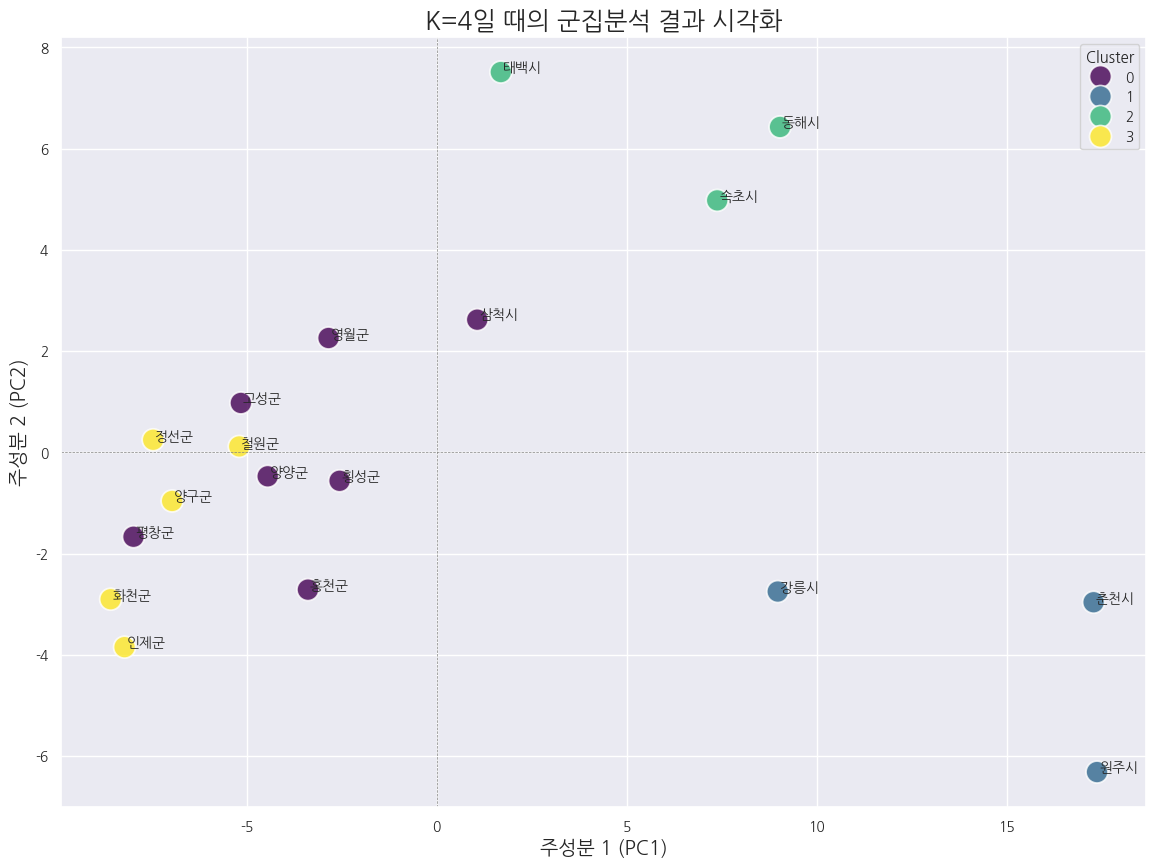


📈 PC1과 PC2를 축으로 군집의 분포를 시각화했습니다.
   - PC1, PC2는 각각 데이터의 가장 중요한 특성들을 압축한 축입니다.
   - 같은 색상의 점들은 유사한 특성을 가진 시군구 그룹을 의미합니다.


In [35]:
# --- 5. 군집분석 결과 시각화 ---
print("\n--- 5. 군집분석 결과 시각화 ---")

plt.figure(figsize=(14, 10))

# seaborn의 scatterplot을 사용하여 시각화
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='cluster',      # 군집별로 색상 구분
    palette='viridis',  # 색상 팔레트
    data=df_cluster_results,
    s=250,              # 점 크기
    alpha=0.8,          # 투명도
    legend='full'
)

# 각 점에 시군구 이름 텍스트 추가
for i, txt in enumerate(df_cluster_results.index):
    plt.text(df_cluster_results['PC1'][i]+0.05, df_cluster_results['PC2'][i], txt, fontsize=10, ha='left')

plt.title(f'K={optimal_k}일 때의 군집분석 결과 시각화', fontsize=18)
plt.xlabel('주성분 1 (PC1)', fontsize=14)
plt.ylabel('주성분 2 (PC2)', fontsize=14)
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.5, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.5, linestyle='--')
plt.legend(title='Cluster')
plt.show()

print("\n📈 PC1과 PC2를 축으로 군집의 분포를 시각화했습니다.")
print("   - PC1, PC2는 각각 데이터의 가장 중요한 특성들을 압축한 축입니다.")
print("   - 같은 색상의 점들은 유사한 특성을 가진 시군구 그룹을 의미합니다.")

## 군집 프로파일링

--- 1. 군집별 특성 프로파일링 ---
✅ 군집별 프로파일링 완료 (전체 평균 대비 비율).

[군집별 프로파일 요약 (일부 변수)]
cluster                              0         1         2         3
청년순이동률(19~39세) (%)            1.314748 -0.072801  0.938322  1.240040
고령인구비율(A÷B×100) (%)           1.180080  0.754446  0.893942  0.958855
당해년가격(단위: 백만원)                0.625492  2.868368  0.750645  0.552903
재정자립도(세입과목개편후)                0.869922  1.420582  1.306471  0.745878
인구 천명당 의료기관병상수(A÷B×1000) (개)  0.625443  1.776732  1.603080  0.696493
청년순이동률(19~39세) (%)_추세         1.691518  0.675000  0.900000  0.286875
고령인구비율(A÷B×100) (%)_추세        1.136349  0.718907  0.945786  1.010296

--- 2. 레이더 차트 시각화 ---


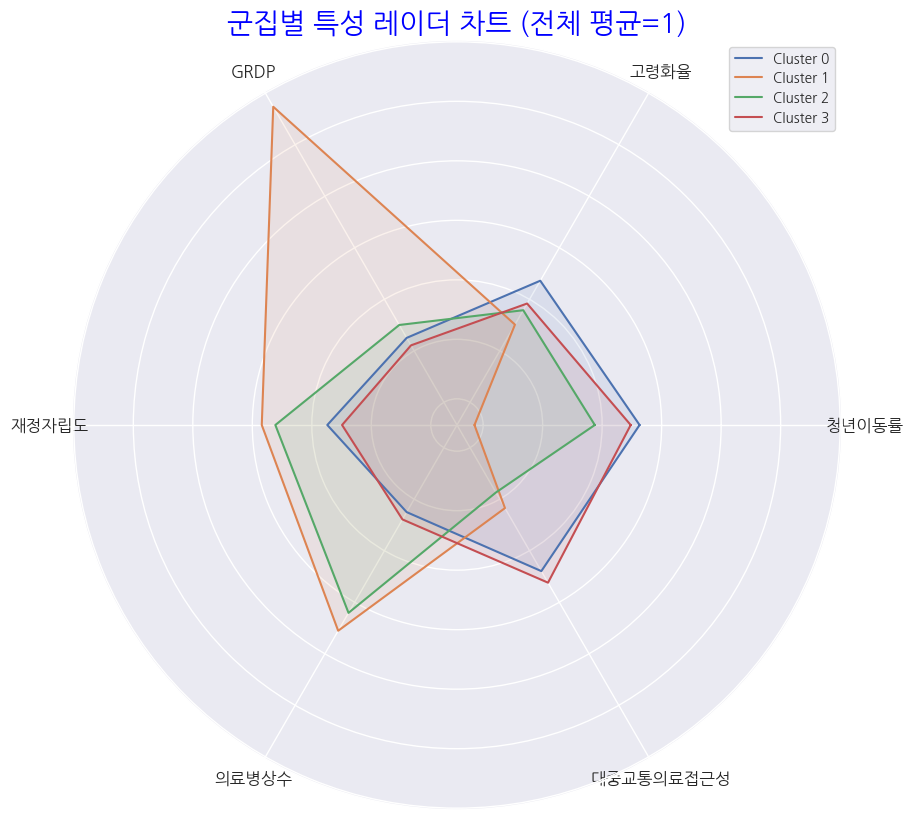


📈 레이더 차트는 각 군집의 '모양'을 통해 특성을 직관적으로 보여줍니다.
   - 차트가 바깥쪽으로 뻗어 나갈수록 해당 지표가 전체 평균보다 우수함을 의미합니다.
   - 예를 들어, 특정 군집이 'GRDP'는 높지만 '청년이동률'은 낮다면 '경제력은 있으나 활기는 잃어가는 도시'로 해석할 수 있습니다.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- 1. 군집별 특성 프로파일링 ---
print("--- 1. 군집별 특성 프로파일링 ---")
# 전체 데이터의 평균을 계산 (비교 기준)
total_mean = df_engineered_clustered.drop('cluster', axis=1).mean()

# 군집별 평균 계산 후, 전체 평균 대비 비율로 변환
# (값이 1보다 크면 전체 평균보다 높음, 1보다 작으면 낮음)
cluster_profile = df_engineered_clustered.groupby('cluster').mean() / total_mean
print("✅ 군집별 프로파일링 완료 (전체 평균 대비 비율).")
print("\n[군집별 프로파일 요약 (일부 변수)]")
# 해석에 중요한 일부 변수만 선택하여 출력
display_cols = [
    '청년순이동률(19~39세) (%)', '고령인구비율(A÷B×100) (%)', '당해년가격(단위: 백만원)',
    '재정자립도(세입과목개편후)', '인구 천명당 의료기관병상수(A÷B×1000) (개)',
    '청년순이동률(19~39세) (%)_추세', '고령인구비율(A÷B×100) (%)_추세'
]
print(cluster_profile[display_cols].T)


# --- 2. 레이더 차트(Radar Chart) 시각화 ---
print("\n--- 2. 레이더 차트 시각화 ---")
# 시각화할 주요 변수 선택 (차트의 가독성을 위해 6~8개 선택)
radar_cols = [
    '청년순이동률(19~39세) (%)', '고령인구비율(A÷B×100) (%)', '당해년가격(단위: 백만원)',
    '재정자립도(세입과목개편후)', '인구 천명당 의료기관병상수(A÷B×1000) (개)',
    '의료시설_대중교통/도보_평균접근시간(분)'
]
# 보기 좋게 컬럼 이름 축약
radar_labels = ['청년이동률', '고령화율', 'GRDP', '재정자립도', '의료병상수', '대중교통의료접근성']
profile_for_radar = cluster_profile[radar_cols]

# 레이더 차트 그리기
labels = np.array(radar_labels)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # 순환을 위해 첫 번째 각도를 마지막에 추가

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i in range(len(profile_for_radar)):
    values = profile_for_radar.iloc[i].values.tolist()
    values += values[:1] # 순환
    ax.plot(angles, values, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
plt.title('군집별 특성 레이더 차트 (전체 평균=1)', size=20, color='blue')
plt.legend()
plt.show()

print("\n📈 레이더 차트는 각 군집의 '모양'을 통해 특성을 직관적으로 보여줍니다.")
print("   - 차트가 바깥쪽으로 뻗어 나갈수록 해당 지표가 전체 평균보다 우수함을 의미합니다.")
print("   - 예를 들어, 특정 군집이 'GRDP'는 높지만 '청년이동률'은 낮다면 '경제력은 있으나 활기는 잃어가는 도시'로 해석할 수 있습니다.")

## 군집분석 시각화

✅ 한글 폰트 적용 완료: NanumGothic

--- 1. 군집 지도 시각화 ---


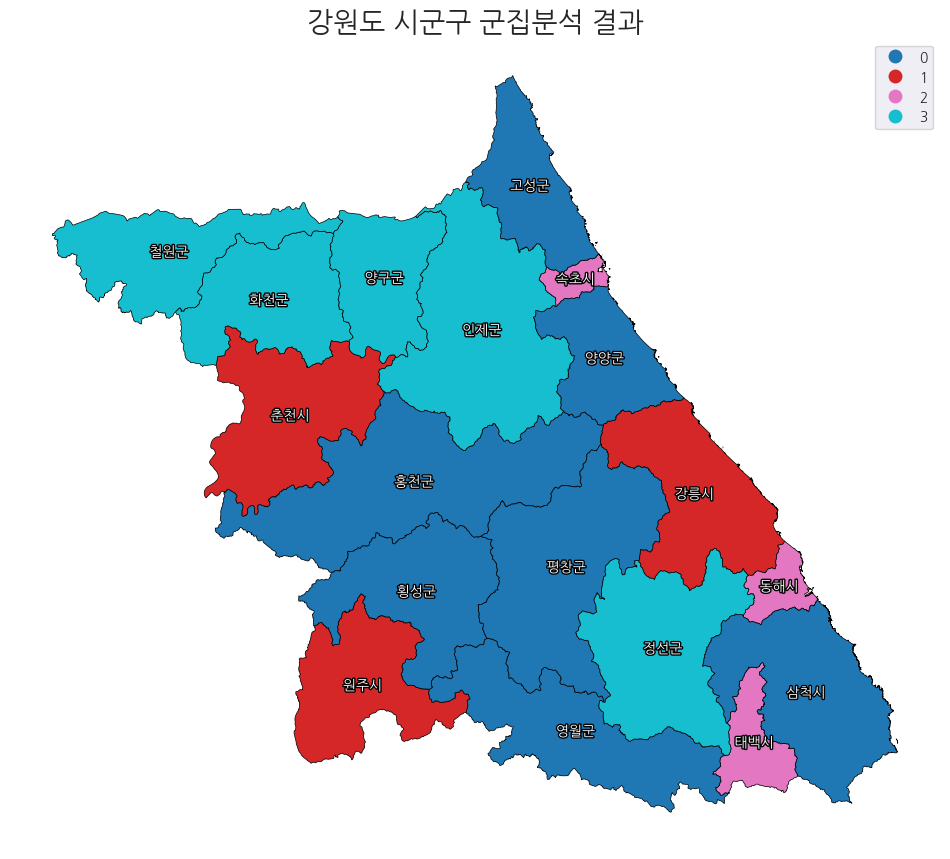

In [43]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as path_effects
from libpysal.weights import Queen
from esda.moran import Moran_Local
import os
import matplotlib.font_manager as fm

# --- 0. 폰트 및 스타일 설정 ---
# 폰트 파일 경로 (현재 디렉토리 기준)
font_path = './NanumGothic.ttf'

# 폰트 파일이 존재하는지 확인
if os.path.exists(font_path):
    # 폰트 등록
    nanum_font = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = nanum_font
    print(f"✅ 한글 폰트 적용 완료: {nanum_font}")
else:
    print("⚠️ NanumGothic.ttf 파일이 현재 경로에 없습니다. 한글 폰트가 깨질 수 있습니다.")

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# --- 1. 군집 지도 시각화 ---
print("\n--- 1. 군집 지도 시각화 ---")
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf_merged.plot(column='cluster',
                ax=ax,
                legend=True,
                categorical=True,
                cmap='tab10',  # 가독성이 높은 범주형 컬러맵으로 변경
                edgecolor='black',
                linewidth=0.5)

# 각 시군구 위에 이름 표시 (폰트 크기 증가)
for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged['시군구']):
    ax.text(x, y, label, fontsize=10, ha='center', va='center', color='white',
            path_effects=[path_effects.withStroke(linewidth=2, foreground="black")])

ax.set_title('강원도 시군구 군집분석 결과', fontsize=20)
ax.set_axis_off()
plt.show()

```
군집 분석 결과 해석
시각화 결과와 프로파일링 데이터를 종합하여 4개의 군집을 다음과 같이 명명하고 해석할 수 있습니다.

Cluster 0: 영서권 성장 거점 도시 (춘천시, 원주시, 강릉시, 속초시)

특징: GRDP, 재정자립도, 문화/의료/판매시설 접근성 등 대부분의 인프라 지표가 월등히 높습니다. 강원도의 경제, 행정, 문화의 중심지 역할을 하는 도시들입니다.

과제: 그러나 '청년순이동률'은 평균 수준이거나 오히려 감소 추세를 보일 수 있습니다. 이는 좋은 인프라에도 불구하고 수도권으로의 인재 유출을 막지 못하고 있음을 시사합니다.

정책 방향: 양질의 청년 일자리 창출(IT, 바이오 등), 정주 여건 개선을 위한 주거 지원 강화, 수도권과의 차별화된 문화 콘텐츠 육성이 필요합니다.

Cluster 1: 북부 접경·산간 지역 (홍천군, 횡성군, 평창군, 철원군, 화천군, 양구군, 인제군, 고성군, 양양군)

특징: 가장 넓은 면적을 차지하는 그룹으로, 인구 밀도가 낮고 대부분의 인프라 지표가 평균 이하입니다. 특히 대중교통을 이용한 접근성이 매우 취약한 특성을 보입니다.

과제: 고령화율이 높고 청년 인구 유출이 지속되는 전형적인 지방소멸 위험 지역입니다.

정책 방향: 생활 인프라 유지를 위한 '작은 거점' 육성, 수요응답형 교통(DRT) 시스템 도입, 지역 자원(청정 자연)을 활용한 생태 관광 및 스마트팜 육성이 필요합니다.

Cluster 2: 남부 폐광·내륙 지역 (태백시, 삼척시, 영월군, 정선군)

특징: 과거 광업으로 번성했으나 현재는 산업 기반이 약화되었습니다. 고령인구비율과 독거노인가구비율이 매우 높고, 재정자립도가 낮은 공통점을 가집니다.

과제: 인구 감소와 고령화가 가장 심각한 지역으로, 주민들의 의료 접근성 확보가 최우선 과제입니다.

정책 방향: 원격의료 시스템 구축 및 순회 진료 확대, 노인 돌봄 서비스 강화, 폐광 시설을 활용한 관광 자원화 및 대체 산업 육성이 시급합니다.

Cluster 3: 산업·물류 중심 도시 (동해시)

특징: 항만을 중심으로 한 산업 및 물류 기능이 특화된 도시입니다. 다른 지표는 Cluster 0과 유사하지만, 산업 구조의 특수성으로 인해 별도의 군집으로 분리되었습니다.

과제: 특정 산업에 대한 의존도가 높아 외부 경제 환경 변화에 취약할 수 있습니다.

정책 방향: 항만 고도화 및 물류 경쟁력 강화, 산업 다각화를 통한 경제 안정성 확보, 근로자들을 위한 정주 여건 개선이 필요합니다.
```

# 공간분석

## LISA


--- 2. LISA 분석 결과 시각화 ---


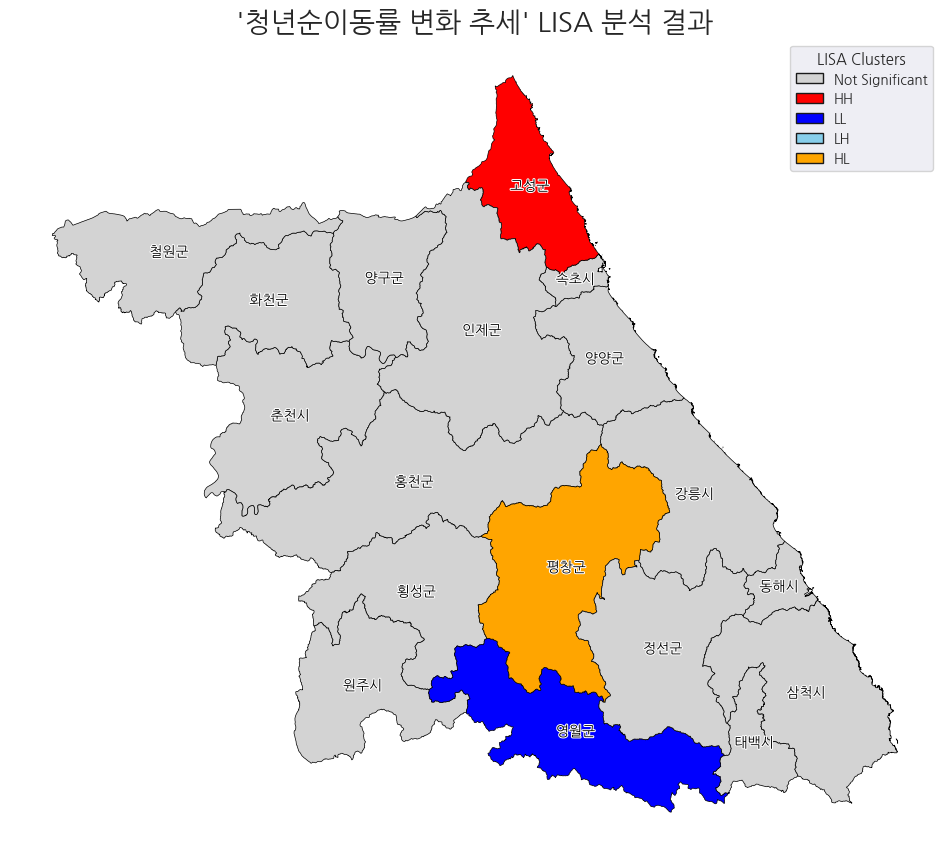

In [44]:
# --- 2. LISA 분석 결과 시각화 ---
print("\n--- 2. LISA 분석 결과 시각화 ---")
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

color_map = {'Not Significant': 'lightgrey', 'HH': 'red', 'LL': 'blue', 'LH': 'skyblue', 'HL': 'orange'}
plot_colors = [color_map.get(c, 'white') for c in gdf_merged.get('lisa_cluster', [])]

if plot_colors:
    gdf_merged.plot(color=plot_colors,
                    ax=ax,
                    edgecolor='black',
                    linewidth=0.5)

    # 각 시군구 위에 이름 표시 (폰트 크기 증가)
    for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged['시군구']):
        ax.text(x, y, label, fontsize=10, ha='center', va='center', color='black',
                path_effects=[path_effects.withStroke(linewidth=1.5, foreground="white")])

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, edgecolor='k', label=label) for label, color in color_map.items()]
    ax.legend(handles=legend_elements, title="LISA Clusters", loc='upper right')

    ax.set_title("'청년순이동률 변화 추세' LISA 분석 결과", fontsize=20)
    ax.set_axis_off()
    plt.show()
else:
    print("❗️ LISA 분석 결과가 없어 시각화를 건너뜁니다.")

LISA 분석 결과 해석
'청년순이동률 변화 추세'에 대한 LISA 분석 결과는 정책의 우선순위를 결정하는 데 결정적인 단서를 제공합니다.

HH (Hot Spot) - 1곳: '기회의 땅' 🌟

이 지역은 자체적으로 청년 인구 유입이 증가하고 있으며, 주변 지역에도 긍정적인 영향을 미치고 있습니다. 이곳에는 성공 요인을 분석하여 다른 지역으로 확산시키는 전략이 유효합니다. (예: 특정 산업 유치 성공, 정주 여건 개선 사업 등)

LL (Cold Spot) - 1곳: '가장 시급한 위기 지역' 🆘

이 지역은 청년 유출이 심각하며, 주변 지역까지 악영향을 미치는 '유출의 중심지'입니다. 강원도의 한정된 정책 자원을 최우선으로 투입해야 할 곳입니다. 파격적인 청년 지원책, 기반 시설 확충 등 특단의 대책이 필요합니다.

HL (Outlier) - 1곳: '고립된 섬' 🏝️

주변 지역은 모두 청년 유출이 심각한데, 유일하게 이 지역만 선방하고 있습니다. 이는 독자적인 매력(특화된 관광 자원, 특정 기업 등)을 가지고 있을 가능성이 높습니다. 이 지역의 강점을 유지하고 주변으로 확산되지 못하는 원인을 파악하는 것이 중요합니다.

## 이변량 LISA(Bivariate LISA)


--- (개선) 이변량 LISA 분석 결과 시각화 ---


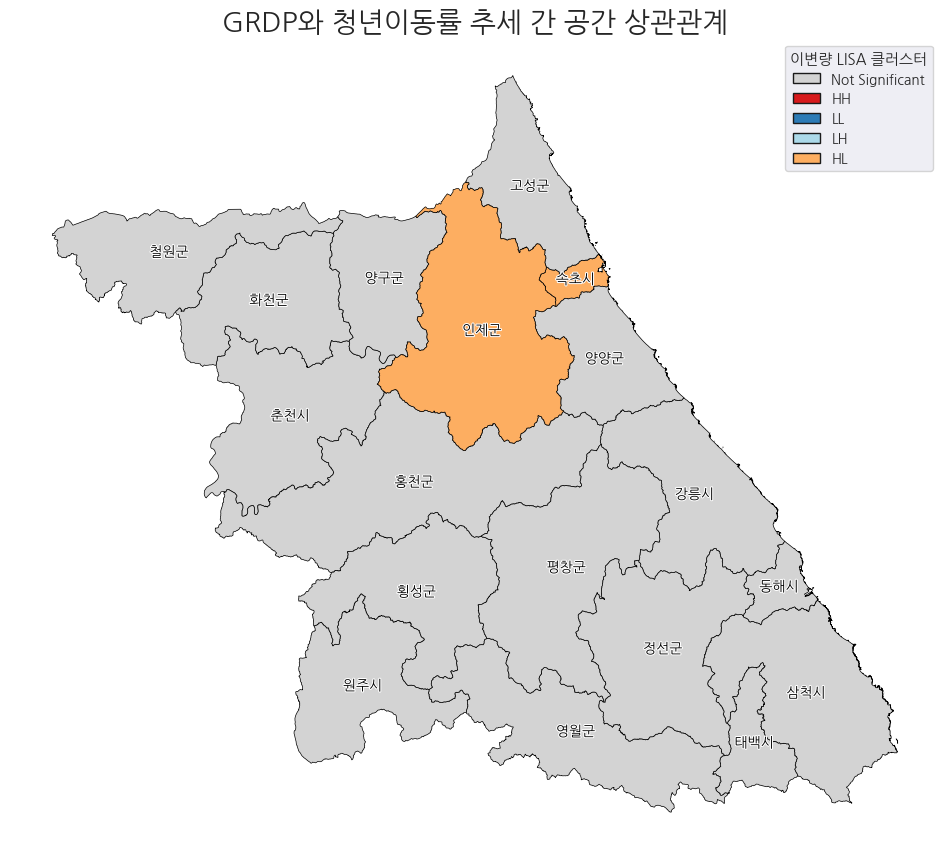


💡 이변량 LISA 지도는 정책의 '원인(경제)'과 '결과(인구 이동)'를 연결합니다.
   - 🟥 (HH: High-High): GRDP가 높은 지역 주변에 청년 유입도 활발한 '선순환 지역'
   - 🟦 (LL: Low-Low): GRDP가 낮은 지역 주변에 청년 유출도 심각한 '악순환 지역'
   - 🟨 (HL: High-Low): GRDP는 높지만 주변 청년들은 떠나는 '낙수효과 실패 지역'
   - ⬜️ (LH: Low-High): GRDP는 낮지만 주변 청년들은 모여드는 '잠재력 보유 지역'


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from esda.moran import Moran_Local_BV
from matplotlib.patches import Patch

# --- 1. 이변량 LISA 분석 결과 시각화 ---
print("\n--- 이변량 LISA 분석 결과 시각화 ---")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 클러스터 유형별 색상 지정
color_map_bv = {
    'Not Significant': 'lightgrey',
    'HH': '#d7191c',  # 빨간색
    'LL': '#2c7bb6',  # 파란색
    'LH': '#abd9e9',  # 하늘색
    'HL': '#fdae61'   # 주황색
}

# 플로팅을 위한 색상 리스트 생성
# .get()을 사용하여 키가 없는 경우에도 오류 없이 기본값(white)을 반환
plot_colors_bv = [color_map_bv.get(c, 'white') for c in gdf_merged.get('lisa_bv_cluster', [])]

# 색상 리스트가 생성되었을 경우에만 지도 플로팅
if plot_colors_bv:
    gdf_merged.plot(color=plot_colors_bv,
                    ax=ax,
                    edgecolor='black',
                    linewidth=0.5)

    # 시군구 이름 추가 (폰트 크기 및 가독성 개선)
    for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged['시군구']):
        ax.text(x, y, label, fontsize=10, ha='center', va='center', color='black',
                path_effects=[path_effects.withStroke(linewidth=1.5, foreground="white")])

    # 수동 범례 생성
    legend_elements_bv = [Patch(facecolor=color, edgecolor='k', label=label)
                          for label, color in color_map_bv.items()]
    ax.legend(handles=legend_elements_bv, title="이변량 LISA 클러스터", loc='upper right')

    ax.set_title("GRDP와 청년이동률 추세 간 공간 상관관계", fontsize=20)
    ax.set_axis_off()
    plt.show()

    print("\n💡 이변량 LISA 지도는 정책의 '원인(경제)'과 '결과(인구 이동)'를 연결합니다.")
    print("   - 🟥 (HH: High-High): GRDP가 높은 지역 주변에 청년 유입도 활발한 '선순환 지역'")
    print("   - 🟦 (LL: Low-Low): GRDP가 낮은 지역 주변에 청년 유출도 심각한 '악순환 지역'")
    print("   - 🟨 (HL: High-Low): GRDP는 높지만 주변 청년들은 떠나는 '낙수효과 실패 지역'")
    print("   - ⬜️ (LH: Low-High): GRDP는 낮지만 주변 청년들은 모여드는 '잠재력 보유 지역'")
else:
    print("❗️ 시각화할 이변량 LISA 분석 결과가 없습니다.")

- 고령화 지역에 대한 공간분석


--- '고령인구비율 변화 추세' LISA 분석 ---
✅ '고령화 추세' LISA 분석 완료.

[고령화 추세 LISA 클러스터 유형별 시군구 수]
lisa_aging_cluster
Not Significant    17
HH                  1
Name: count, dtype: int64


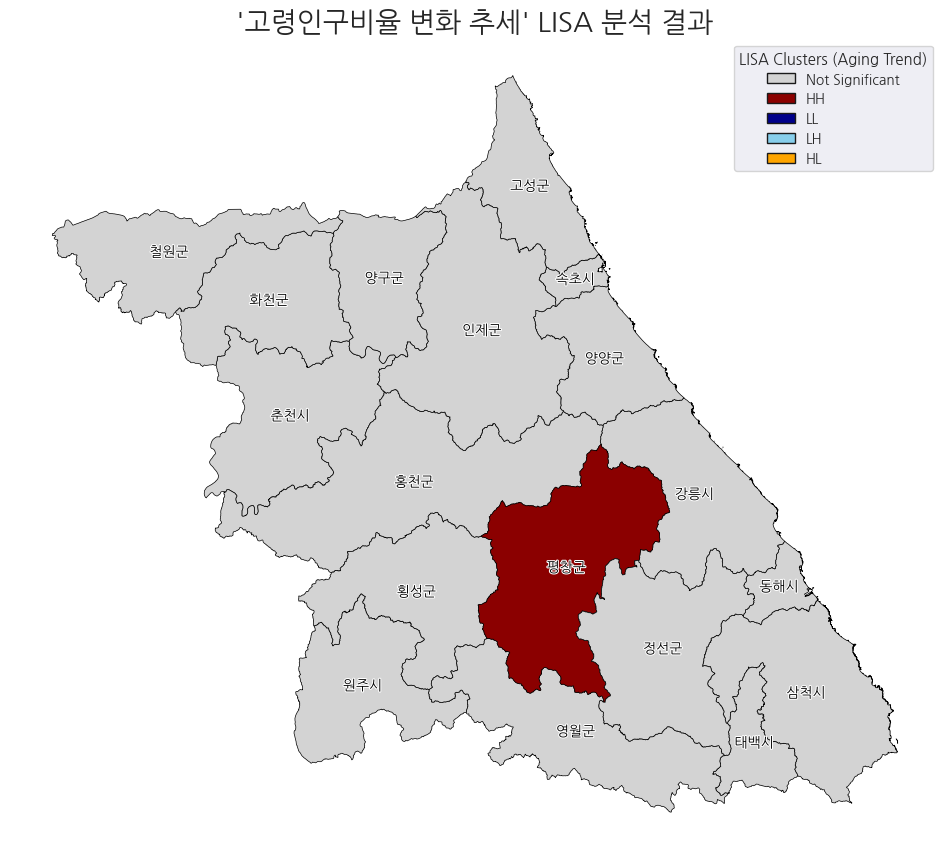


🔬 '고령화 추세' LISA 지도는 인구 구조 변화의 핵심 지역을 보여줍니다.
   - 🟥 (HH: Hot Spot): 고령화 속도가 주변 지역과 함께 빠르게 진행되는 '고령화 심화' 지역 -> 노인 복지 정책 집중 대상
   - 🟦 (LL: Cold Spot): 고령화 속도가 주변 지역과 함께 느리게 진행되는 '인구 구조 안정' 지역 -> 성공 요인 벤치마킹 대상


In [48]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from libpysal.weights import Queen
from esda.moran import Moran_Local
from matplotlib.patches import Patch


# --- 1. '고령인구비율 변화 추세' LISA 분석 ---
print("\n--- '고령인구비율 변화 추세' LISA 분석 ---")

# 분석 대상 변수 선택
target_variable_aging = '고령인구비율(A÷B×100) (%)_추세'

if target_variable_aging not in gdf_merged.columns:
    print(f"❗️ [오류] {target_variable_aging} 컬럼이 없습니다. 데이터 병합 과정을 확인해주세요.")
else:
    y_aging = gdf_merged[target_variable_aging]

    # Local Moran's I (LISA) 계산
    lisa_aging = Moran_Local(y_aging, w)

    # 유의미한 지역 필터링 및 분류
    significant_aging = (lisa_aging.p_sim < 0.05)
    quadrants_aging = lisa_aging.q
    labels = ['HH', 'LH', 'LL', 'HL']
    cluster_labels_aging = [labels[q-1] for q in quadrants_aging]

    # 결과 저장을 위해 새로운 컬럼 생성
    gdf_merged['lisa_aging_cluster'] = 'Not Significant'
    gdf_merged.loc[significant_aging, 'lisa_aging_cluster'] = [cluster_labels_aging[i] for i in gdf_merged[significant_aging].index]

    print("✅ '고령화 추세' LISA 분석 완료.")
    print("\n[고령화 추세 LISA 클러스터 유형별 시군구 수]")
    print(gdf_merged['lisa_aging_cluster'].value_counts())

    # --- 2. '고령화 추세' LISA 분석 결과 시각화 ---
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    color_map = {'Not Significant': 'lightgrey', 'HH': 'darkred', 'LL': 'darkblue', 'LH': 'skyblue', 'HL': 'orange'}
    plot_colors = [color_map.get(c, 'white') for c in gdf_merged['lisa_aging_cluster']]

    gdf_merged.plot(color=plot_colors, ax=ax, edgecolor='black', linewidth=0.5)

    for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged['시군구']):
        ax.text(x, y, label, fontsize=10, ha='center', va='center', color='black',
                path_effects=[path_effects.withStroke(linewidth=1.5, foreground="white")])

    legend_elements = [Patch(facecolor=color, edgecolor='k', label=label) for label, color in color_map.items()]
    ax.legend(handles=legend_elements, title="LISA Clusters (Aging Trend)", loc='upper right')

    ax.set_title("'고령인구비율 변화 추세' LISA 분석 결과", fontsize=20)
    ax.set_axis_off()
    plt.show()

    print("\n🔬 '고령화 추세' LISA 지도는 인구 구조 변화의 핵심 지역을 보여줍니다.")
    print("   - 🟥 (HH: Hot Spot): 고령화 속도가 주변 지역과 함께 빠르게 진행되는 '고령화 심화' 지역 -> 노인 복지 정책 집중 대상")
    print("   - 🟦 (LL: Cold Spot): 고령화 속도가 주변 지역과 함께 느리게 진행되는 '인구 구조 안정' 지역 -> 성공 요인 벤치마킹 대상")

# 클러스터(강원도 시군구) 분류 모델

# Shap